<a href="https://colab.research.google.com/github/Jerrylu99/Econ-5200-Project/blob/main/notebooks/02_Replication_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 - Replication Analysis
## ECON 5200 Project

This notebook performs the replication analysis of Card and Krueger (1994).

The analysis uses the cleaned dataset produced in Phase 1 and implements a Difference-in-Differences (DID) approach to estimate the impact of the New Jersey minimum wage increase on fast-food employment.

Steps in this notebook:
- load cleaned data
- descriptive statistics
- manual DID calculation
- regression estimation
- clustered standard errors

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Jerrylu99/Econ-5200-Project/main/data/processed/cleaned_data.csv")

In [ ]:
df[["fte_before","fte_after","wage_st","wage_st2"]].describe()

,fte_before,fte_after,wage_st,wage_st2
count,384.000000,384.000000,365.000000,369.000000
mean,21.006641,20.936198,4.613178,4.994444
std,9.874065,9.183605,0.345862,0.255440
min,5.000000,0.000000,4.250000,4.250000
25%,14.500000,14.250000,4.250000,5.050000
50%,19.500000,20.000000,4.500000,5.050000
75%,24.500000,26.500000,4.950000,5.050000
max,85.000000,60.500000,5.750000,6.250000


In [ ]:
df.groupby("state")[["fte_before","fte_after"]].mean()

,fte_before,fte_after
state,,
0,23.380000,21.096667
1,20.430583,20.897249


In [ ]:
nj_before = df.loc[df["state"]==1,"fte_before"].mean()
nj_after  = df.loc[df["state"]==1,"fte_after"].mean()

pa_before = df.loc[df["state"]==0,"fte_before"].mean()
pa_after  = df.loc[df["state"]==0,"fte_after"].mean()

did = (nj_after - nj_before) - (pa_after - pa_before)

print("DID estimate:", did)

DID estimate: 2.7499999999999964


In [ ]:
before = df[["sheet","state","fte_before"]].copy()
before["post"] = 0
before = before.rename(columns={"fte_before":"fte"})

after = df[["sheet","state","fte_after"]].copy()
after["post"] = 1
after = after.rename(columns={"fte_after":"fte"})

panel = pd.concat([before,after])

panel["treat"] = panel["state"]
panel["did"] = panel["treat"] * panel["post"]

panel.head()

,sheet,state,fte,post,treat,did
0,46,0,40.50,0,0,0
1,49,0,13.75,0,0,0
2,506,0,8.50,0,0,0
3,56,0,34.00,0,0,0
4,61,0,24.00,0,0,0


In [ ]:
panel.groupby(["treat","post"])["fte"].mean().unstack()

post,0,1
treat,,
0,23.380000,21.096667
1,20.430583,20.897249


In [ ]:
model = smf.ols("fte ~ treat + post + did", data=panel).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.947
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.121
Time:                        01:36:37   Log-Likelihood:                -2817.6
No. Observations:                 768   AIC:                             5643.
Df Residuals:                     764   BIC:                             5662.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3800      1.098     21.288      0.0

In [ ]:
model_cluster = smf.ols("fte ~ treat + post + did", data=panel).fit(
    cov_type="cluster",
    cov_kwds={"groups":panel["sheet"]}
)

print(model_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.658
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.176
Time:                        01:37:31   Log-Likelihood:                -2817.6
No. Observations:                 768   AIC:                             5643.
Df Residuals:                     764   BIC:                             5662.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3800      1.382     16.917      0.0

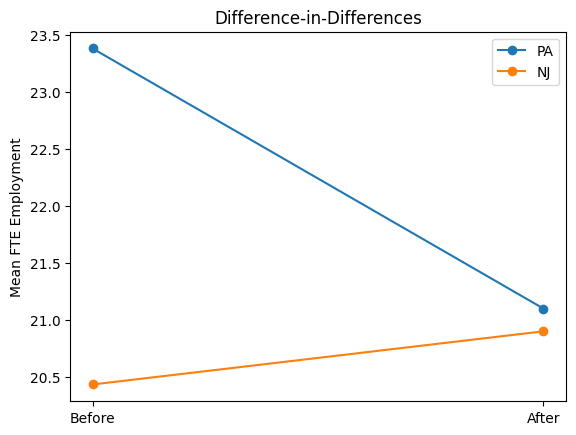

In [ ]:
plot = panel.groupby(["treat","post"])["fte"].mean().reset_index()

for g,label in [(0,"PA"),(1,"NJ")]:
    temp = plot[plot["treat"]==g]
    plt.plot(temp["post"],temp["fte"],marker="o",label=label)

plt.xticks([0,1],["Before","After"])
plt.ylabel("Mean FTE Employment")
plt.title("Difference-in-Differences")
plt.legend()

plt.show()

## Discussion

This analysis replicates the DID framework used in Card and Krueger (1994).
The treatment group consists of restaurants in New Jersey, where the minimum wage increased, while Pennsylvania serves as the control group.

The manual DID calculation compares the change in employment between the two states before and after the policy change.
The regression results confirm this estimate using a formal econometric model.

Clustered standard errors are used to account for correlation within stores across time.

Overall, the results illustrate how natural experiments can be used to evaluate policy impacts.

---

